In [ ]:
!pip install planetary-computer pystac-client odc-stac
!pip install scikit-learn xgboost pandas numpy matplotlib requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 11.3 MB/s eta 0:00:00


In [ ]:
import planetary_computer
import pystac_client
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import io
import warnings
warnings.filterwarnings('ignore')

from odc.stac import load
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb

print("All libraries loaded successfully")

All libraries loaded successfully


In [ ]:
ZONES = {
    "western_ghats": {
        "name":        "Western Ghats",
        "bbox":        [74.0, 8.0, 77.5, 15.0],
        "lat":         11.5,
        "lng":         75.8,
        "iks_region":  "Kerala sacred groves — Kavus",
        "description": "Biodiversity hotspot, Kerala-Karnataka border"
    },
    "central_india": {
        "name":        "Central India Forests",
        "bbox":        [78.0, 18.0, 83.0, 24.0],
        "lat":         21.5,
        "lng":         80.5,
        "iks_region":  "Gond tribal forest knowledge",
        "description": "Sal and teak forests, Madhya Pradesh"
    },
    "northeast": {
        "name":        "Northeast Forests",
        "bbox":        [89.0, 24.0, 97.0, 28.0],
        "lat":         26.0,
        "lng":         93.0,
        "iks_region":  "Khasi sacred forests — Law Kyntang",
        "description": "Evergreen forests, Assam-Meghalaya"
    }
}

print("Zones defined:")
for key, zone in ZONES.items():
    print(f"  {key}: {zone['name']}")

Zones defined:
  western_ghats: Western Ghats
  central_india: Central India Forests
  northeast: Northeast Forests


In [ ]:
#4th
FIRMS_API_KEY = "3688a13fd8122120e416c4ac51616c06"

def fetch_fire_data():
    print("Fetching NASA FIRMS fire data...")

    # Max allowed is 5 days
    url = (
        "https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
        + FIRMS_API_KEY
        + "/VIIRS_SNPP_NRT/74,8,97,28/5"
    )

    response = requests.get(url, timeout=30)
    print(f"Status: {response.status_code}")

    if response.status_code != 200:
        print(f"Error: {response.text}")
        return pd.DataFrame(columns=[
            "latitude","longitude","acq_date","confidence"
        ])

    df_fire = pd.read_csv(io.StringIO(response.text))
    print(f"Fire detections: {len(df_fire)}")

    if len(df_fire) == 0:
        print("No fires detected in last 5 days")
        print("Pipeline continues with zero fire data")
        return pd.DataFrame(columns=[
            "latitude","longitude","acq_date","confidence"
        ])

    print(df_fire.head(3))
    df_fire.to_csv("india_fire_data.csv", index=False)
    print("Saved: india_fire_data.csv")
    return df_fire

df_fire_raw = fetch_fire_data()

Fetching NASA FIRMS fire data...
Status: 200
Fire detections: 31270
   latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \
0  19.21810   96.67777      340.31  0.79   0.78  2026-03-31       553   
1  19.22869   96.90318      331.97  0.76   0.77  2026-03-31       553   
2  19.27023   96.85888      349.42  0.77   0.77  2026-03-31       553   

  satellite instrument confidence version  bright_ti5     frp daynight  
0         N      VIIRS          n  2.0NRT      294.30    9.12        D  
1         N      VIIRS          n  2.0NRT      295.46    7.28        D  
2         N      VIIRS          n  2.0NRT      296.95  226.04        D  
Saved: india_fire_data.csv


In [ ]:
#5th cell
def clean_fire_data(df_fire):
    if len(df_fire) == 0:
        print("No fire data available — skipping fire cleaning")
        return pd.DataFrame(columns=["zone", "month_year", "fire_count"])

    print(f"Raw fire records: {len(df_fire)}")

    # VIIRS uses "l" for low confidence — not "low"
    if "confidence" in df_fire.columns:
        df_fire = df_fire[df_fire["confidence"] != "l"].copy()

    df_fire["acq_date"] = pd.to_datetime(df_fire["acq_date"])

    def assign_zone(row):
        checks = {
            "western_ghats": (8,  15, 74, 77.5),
            "central_india":  (18, 24, 78, 83),
            "northeast":      (24, 28, 89, 97)
        }
        for zone, (s, n, w, e) in checks.items():
            if s <= row.latitude <= n and w <= row.longitude <= e:
                return zone
        return "other"

    df_fire["zone"] = df_fire.apply(assign_zone, axis=1)
    df_fire = df_fire[df_fire["zone"] != "other"].copy()
    print(f"Fire records inside our zones: {len(df_fire)}")

    df_fire["month_year"] = df_fire["acq_date"].dt.to_period("M")
    fire_monthly = df_fire.groupby(
        ["zone", "month_year"]
    ).size().reset_index(name="fire_count")

    print("Monthly fire counts per zone:")
    print(fire_monthly)
    return fire_monthly

fire_monthly = clean_fire_data(df_fire_raw)

Raw fire records: 31270
Fire records inside our zones: 3781
Monthly fire counts per zone:
            zone month_year  fire_count
0  central_india    2026-03         426
1  central_india    2026-04        1296
2      northeast    2026-03          36
3      northeast    2026-04        1898
4  western_ghats    2026-03          18
5  western_ghats    2026-04         107


In [ ]:
#6th
def fetch_ndvi(zone_name):
    zone = ZONES[zone_name]
    print(f"\nFetching satellite data for: {zone['name']}")

    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=planetary_computer.sign_inplace,
    )

    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=zone["bbox"],
        datetime="2020-01-01/2024-12-31",
        query={"eo:cloud_cover": {"lt": 20}},
    )

    items = list(search.items())
    print(f"Total images found: {len(items)}")

    # Take more images — 150 instead of 50
    # More data = better model
    items = sorted(items, key=lambda x: x.datetime)
    step = max(1, len(items) // 150)
    sampled = items[::step][:150]
    print(f"Using {len(sampled)} sampled images")

    ds = load(
        sampled,
        bands=["B04", "B08"],
        resolution=1000,
        groupby="time",
    )

    red = ds["B04"].astype(float)
    nir = ds["B08"].astype(float)
    ndvi = (nir - red) / (nir + red + 1e-10)
    ndvi_mean = ndvi.mean(dim=["x", "y"])

    df = ndvi_mean.to_series().reset_index()
    df.columns = [*df.columns[:-1], "ndvi"]
    df = df[["time", "ndvi"]].copy()
    df = df.rename(columns={"time": "date"})

    # Light filtering
    df = df[(df["ndvi"] > 0.1) & (df["ndvi"] < 0.95)].copy()
    df = df.sort_values("date").reset_index(drop=True)

    # Keep as weekly instead of monthly
    # Weekly gives 4x more data points
    df["date"] = pd.to_datetime(df["date"])
    df = df.groupby(df["date"].dt.to_period("W")).agg(
        {"ndvi": "mean"}
    ).reset_index()
    df["date"] = df["date"].astype(str)
    df["zone"] = zone_name

    print(f"Final data points: {len(df)}")
    print(df.head(5))
    return df

In [ ]:
print("Starting fetch...")
df_wg_raw = fetch_ndvi("western_ghats")
print("Done")
print(df_wg_raw.head())

Starting fetch...

Fetching satellite data for: Western Ghats
Total images found: 8772
Using 150 sampled images
Final data points: 74
                    date      ndvi           zone
0  2019-12-30/2020-01-05  0.108040  western_ghats
1  2020-01-06/2020-01-12  0.100176  western_ghats
2  2020-01-27/2020-02-02  0.169932  western_ghats
3  2020-02-10/2020-02-16  0.363032  western_ghats
4  2020-02-17/2020-02-23  0.344369  western_ghats
Done
                    date      ndvi           zone
0  2019-12-30/2020-01-05  0.108040  western_ghats
1  2020-01-06/2020-01-12  0.100176  western_ghats
2  2020-01-27/2020-02-02  0.169932  western_ghats
3  2020-02-10/2020-02-16  0.363032  western_ghats
4  2020-02-17/2020-02-23  0.344369  western_ghats


In [ ]:
# Fix the raw data before passing to clean_ndvi
def fix_raw_data(df, zone_name):
    # Remove low NDVI — raise threshold slightly
    df = df[df["ndvi"] > 0.15].copy()

    # Fix date — take just the start date of each week
    df["date"] = df["date"].astype(str).str[:10]

    # Remove any remaining duplicates
    df = df.drop_duplicates(subset="date").reset_index(drop=True)

    print(f"Fixed data points for {zone_name}: {len(df)}")
    print(df.head(3))
    return df

df_wg_raw = fix_raw_data(df_wg_raw, "western_ghats")

Fixed data points for western_ghats: 69
         date      ndvi           zone
0  2020-01-27  0.169932  western_ghats
1  2020-02-10  0.363032  western_ghats
2  2020-02-17  0.344369  western_ghats


In [ ]:
#7th cell
# Only run this after Cell 6 succeeds

df_ci_raw = fetch_ndvi("central_india")
df_ne_raw = fetch_ndvi("northeast")

print("\nAll 3 zones fetched:")
print(f"Western Ghats:  {len(df_wg_raw)} records")
print(f"Central India:  {len(df_ci_raw)} records")
print(f"Northeast:      {len(df_ne_raw)} records")


Fetching satellite data for: Central India Forests
Total images found: 19770
Using 150 sampled images
Final data points: 125
                    date      ndvi           zone
0  2019-12-30/2020-01-05  0.464152  central_india
1  2020-01-13/2020-01-19  0.405264  central_india
2  2020-01-20/2020-01-26  0.418006  central_india
3  2020-02-03/2020-02-09  0.458982  central_india
4  2020-02-10/2020-02-16  0.453938  central_india

Fetching satellite data for: Northeast Forests
Total images found: 13520
Using 150 sampled images
Final data points: 119
                    date      ndvi       zone
0  2020-01-06/2020-01-12  0.641733  northeast
1  2020-01-13/2020-01-19  0.484165  northeast
2  2020-01-20/2020-01-26  0.696622  northeast
3  2020-01-27/2020-02-02  0.356131  northeast
4  2020-02-03/2020-02-09  0.267325  northeast

All 3 zones fetched:
Western Ghats:  69 records
Central India:  125 records
Northeast:      119 records


In [ ]:
#8 cell
def clean_ndvi(df, zone_name):
    if len(df) == 0:
        print(f"No data for {zone_name}")
        return df

    print(f"\nCleaning {zone_name}:")
    print(f"Before: {len(df)} rows")

    # Remove cloud contamination
    # Clouds give NDVI below 0.1
    # Real healthy forest is always above 0.2
    df = df[df["ndvi"] > 0.1].copy()

    # Remove sensor errors
    # NDVI above 0.95 is physically impossible
    df = df[df["ndvi"] < 0.95].copy()

    # Sort oldest to newest
    df = df.sort_values("date").reset_index(drop=True)

    # Remove duplicate dates
    df = df.drop_duplicates(subset="date").reset_index(drop=True)

    # Interpolate small gaps
    # If 1 or 2 values are missing between valid readings
    # estimate them from neighboring values
    df["ndvi"] = df["ndvi"].interpolate(method="linear", limit=2)

    print(f"After:  {len(df)} rows")
    print(f"NDVI range: {df['ndvi'].min():.3f} to {df['ndvi'].max():.3f}")
    return df

# Clean all 3 zones
df_wg = clean_ndvi(df_wg_raw, "western_ghats")
df_ci = clean_ndvi(df_ci_raw, "central_india")
df_ne = clean_ndvi(df_ne_raw, "northeast")


Cleaning western_ghats:
Before: 69 rows
After:  69 rows
NDVI range: 0.154 to 0.727

Cleaning central_india:
Before: 125 rows
After:  125 rows
NDVI range: 0.104 to 0.650

Cleaning northeast:
Before: 119 rows
After:  119 rows
NDVI range: 0.153 to 0.897


In [ ]:
df_ci_raw = fix_raw_data(df_ci_raw, "central_india")
df_ne_raw = fix_raw_data(df_ne_raw, "northeast")

print("\nFinal clean counts:")
print(f"Western Ghats:  {len(df_wg_raw)}")
print(f"Central India:  {len(df_ci_raw)}")
print(f"Northeast:      {len(df_ne_raw)}")

Fixed data points for central_india: 119
         date      ndvi           zone
0  2019-12-30  0.464152  central_india
1  2020-01-13  0.405264  central_india
2  2020-01-20  0.418006  central_india
Fixed data points for northeast: 119
         date      ndvi       zone
0  2020-01-06  0.641733  northeast
1  2020-01-13  0.484165  northeast
2  2020-01-20  0.696622  northeast

Final clean counts:
Western Ghats:  69
Central India:  119
Northeast:      119


In [ ]:
#9th cell
def extract_features(df, zone_name):
    if len(df) == 0:
        return df

    print(f"\nExtracting features for {zone_name}:")

    # Fix date format first — handles both "2020-01-15" and "2020-01-13/2020-01-19"
    df["date"] = df["date"].astype(str).str[:10]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).reset_index(drop=True)

    # Feature 1: 7-day rolling average
    df["ndvi_7day"] = df["ndvi"].rolling(7, min_periods=1).mean()

    # Feature 2: 30-day rolling average
    df["ndvi_30day"] = df["ndvi"].rolling(30, min_periods=1).mean()

    # Feature 3: Rate of change
    df["ndvi_change"] = df["ndvi"].diff()

    # Feature 4: Stability
    df["ndvi_std"] = df["ndvi"].rolling(7, min_periods=1).std()

    # Feature 5: Month number
    df["month"] = df["date"].dt.month

    # Feature 6: Seasonal deviation
    monthly_avg = df.groupby("month")["ndvi"].transform("mean")
    df["ndvi_seasonal_dev"] = df["ndvi"] - monthly_avg

    # Feature 7: 90-day trend
    df["ndvi_90day"] = df["ndvi"].rolling(90, min_periods=1).mean()

    # Feature 8: Ratio vs long term
    df["ndvi_ratio"] = df["ndvi"] / (df["ndvi_90day"] + 1e-6)

    # Convert date back to string for export
    df["date"] = df["date"].astype(str)

    df = df.fillna(0)
    print(f"Features created: {list(df.columns)}")
    return df

# Extract features for all 3 zones
df_wg = extract_features(df_wg, "western_ghats")
df_ci = extract_features(df_ci, "central_india")
df_ne = extract_features(df_ne, "northeast")


Extracting features for western_ghats:
Features created: ['date', 'ndvi', 'zone', 'ndvi_7day', 'ndvi_30day', 'ndvi_change', 'ndvi_std', 'month', 'ndvi_seasonal_dev', 'ndvi_90day', 'ndvi_ratio']

Extracting features for central_india:
Features created: ['date', 'ndvi', 'zone', 'ndvi_7day', 'ndvi_30day', 'ndvi_change', 'ndvi_std', 'month', 'ndvi_seasonal_dev', 'ndvi_90day', 'ndvi_ratio']

Extracting features for northeast:
Features created: ['date', 'ndvi', 'zone', 'ndvi_7day', 'ndvi_30day', 'ndvi_change', 'ndvi_std', 'month', 'ndvi_seasonal_dev', 'ndvi_90day', 'ndvi_ratio']


In [ ]:
#10th
def merge_fire_data(df_ndvi, fire_monthly, zone_name):
    if len(df_ndvi) == 0:
        return df_ndvi

    print(f"\nMerging fire data for {zone_name}:")

    # FIRMS data is current (2026) but NDVI is historical (2020-2024)
    # They don't overlap by date — that's fine
    # Instead use total recent fire count as a zone-level risk indicator
    # This represents current fire pressure on this zone

    if len(fire_monthly) > 0:
        zone_fires = fire_monthly[fire_monthly["zone"] == zone_name]
        total_recent_fires = zone_fires["fire_count"].sum()
    else:
        total_recent_fires = 0

    # Add as constant column — same value for all rows in this zone
    # This tells the model: this zone currently has X fires happening
    df_ndvi["fire_count"] = total_recent_fires

    print(f"Recent fire count for {zone_name}: {total_recent_fires}")
    return df_ndvi

df_wg = merge_fire_data(df_wg, fire_monthly, "western_ghats")
df_ci = merge_fire_data(df_ci, fire_monthly, "central_india")
df_ne = merge_fire_data(df_ne, fire_monthly, "northeast")

print("\nFire counts per zone:")
print(f"  Western Ghats:  {df_wg['fire_count'].iloc[0]}")
print(f"  Central India:  {df_ci['fire_count'].iloc[0]}")
print(f"  Northeast:      {df_ne['fire_count'].iloc[0]}")


Merging fire data for western_ghats:
Recent fire count for western_ghats: 125

Merging fire data for central_india:
Recent fire count for central_india: 1722

Merging fire data for northeast:
Recent fire count for northeast: 1934

Fire counts per zone:
  Western Ghats:  125
  Central India:  1722
  Northeast:      1934


In [ ]:
#11 th
def run_isolation_forest(df, zone_name):
    if len(df) < 10:
        print(f"Not enough data for {zone_name}")
        return df

    print(f"\nRunning Isolation Forest for {zone_name}:")

    # These are the features we feed the model
    features = [
        "ndvi",
        "ndvi_7day",
        "ndvi_30day",
        "ndvi_change",
        "ndvi_std",
        "ndvi_seasonal_dev",
        "fire_count",
        "month"
    ]

    X = df[features].fillna(0).values

    # Normalize — put all features on same scale
    # After this, every feature has mean=0 and std=1
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train Isolation Forest
    # contamination=0.1 → expect 10% anomalies
    iso = IsolationForest(
        contamination=0.1,
        random_state=42,
        n_estimators=100
    )
    iso.fit(X_scaled)

    # -1 = anomaly, +1 = normal
    df["anomaly"] = iso.predict(X_scaled)

    # Anomaly score — more negative = more anomalous
    df["anomaly_score"] = iso.score_samples(X_scaled)

    n_anomalies = (df["anomaly"] == -1).sum()
    print(f"Anomalies detected: {n_anomalies} / {len(df)}")
    print(f"Score range: {df['anomaly_score'].min():.3f} to {df['anomaly_score'].max():.3f}")
    return df

# Run for all 3 zones
df_wg = run_isolation_forest(df_wg, "western_ghats")
df_ci = run_isolation_forest(df_ci, "central_india")
df_ne = run_isolation_forest(df_ne, "northeast")


Running Isolation Forest for western_ghats:
Anomalies detected: 7 / 69
Score range: -0.676 to -0.393

Running Isolation Forest for central_india:
Anomalies detected: 13 / 125
Score range: -0.636 to -0.410

Running Isolation Forest for northeast:
Anomalies detected: 12 / 119
Score range: -0.630 to -0.418


In [ ]:
#12th — skip labeling, not needed without XGBoost
print("Skipping label creation — using weighted risk formula instead")
print("XGBoost requires 500+ labeled data points to work reliably")
print("Our dataset has 69-125 points — weighted formula is more appropriate")

# Add dummy label column so Cell 13 doesn't break
df_wg["label"] = 0
df_ci["label"] = 0
df_ne["label"] = 0

Skipping label creation — using weighted risk formula instead
XGBoost requires 500+ labeled data points to work reliably
Our dataset has 69-125 points — weighted formula is more appropriate


In [ ]:
#13th — skip XGBoost
print("Skipping XGBoost training")
print("Using weighted risk formula in Cell 14 instead")
print("This is more reliable for small datasets")

# Set model variables to None so Cell 14 doesn't break
model_wg = None
model_ci = None
model_ne = None
features = None

Skipping XGBoost training
Using weighted risk formula in Cell 14 instead
This is more reliable for small datasets


In [ ]:
#14th
def generate_risk_scores(df, model, features, zone_name):
    if len(df) == 0:
        return df

    print(f"\nGenerating risk scores for {zone_name}:")

    def calculate_risk(row):
        score = 0

        # Signal 1: Seasonal deviation (max 35 points)
        if row["ndvi_seasonal_dev"] < 0:
            score += min(35, abs(row["ndvi_seasonal_dev"]) * 120)

        # Signal 2: Low NDVI level (max 25 points)
        if row["ndvi"] < 0.5:
            score += min(25, (0.5 - row["ndvi"]) * 80)

        # Signal 3: Anomaly score (max 20 points)
        score += min(20, abs(row["anomaly_score"]) * 30)

        # Signal 4: Fire count (max 20 points)
        # Fixed multiplier — scales properly with real fire counts
        # 0 fires = 0 points
        # 500 fires = 10 points
        # 1500+ fires = 20 points
        fire = row.get("fire_count", 0)
        score += min(20, (fire / 1500) * 20)

        return round(min(100, max(0, score)), 1)

    def assign_level(score):
        if score < 25:  return "LOW"
        if score < 50:  return "MODERATE"
        if score < 75:  return "HIGH"
        return "CRITICAL"

    df["risk_score"] = df.apply(calculate_risk, axis=1)
    df["risk_level"] = df["risk_score"].apply(assign_level)

    print(f"Score range: {df['risk_score'].min()} to {df['risk_score'].max()}")
    print(df["risk_level"].value_counts())
    print(f"\nLatest:")
    print(f"  NDVI:       {df.iloc[-1]['ndvi']:.3f}")
    print(f"  Fire count: {df.iloc[-1]['fire_count']}")
    print(f"  Risk Score: {df.iloc[-1]['risk_score']}")
    print(f"  Risk Level: {df.iloc[-1]['risk_level']}")
    return df

df_wg = generate_risk_scores(df_wg, model_wg, features, "western_ghats")
df_ci = generate_risk_scores(df_ci, model_ci, features, "central_india")
df_ne = generate_risk_scores(df_ne, model_ne, features, "northeast")


Generating risk scores for western_ghats:
Score range: 17.8 to 61.7
risk_level
MODERATE    43
HIGH        13
LOW         13
Name: count, dtype: int64

Latest:
  NDVI:       0.365
  Fire count: 125
  Risk Score: 30.9
  Risk Level: MODERATE

Generating risk scores for central_india:
Score range: 34.3 to 90.6
risk_level
HIGH        68
MODERATE    50
CRITICAL     7
Name: count, dtype: int64

Latest:
  NDVI:       0.333
  Fire count: 1722
  Risk Score: 47.4
  Risk Level: MODERATE

Generating risk scores for northeast:
Score range: 34.0 to 98.6
risk_level
MODERATE    65
HIGH        44
CRITICAL    10
Name: count, dtype: int64

Latest:
  NDVI:       0.394
  Fire count: 1934
  Risk Score: 44.9
  Risk Level: MODERATE


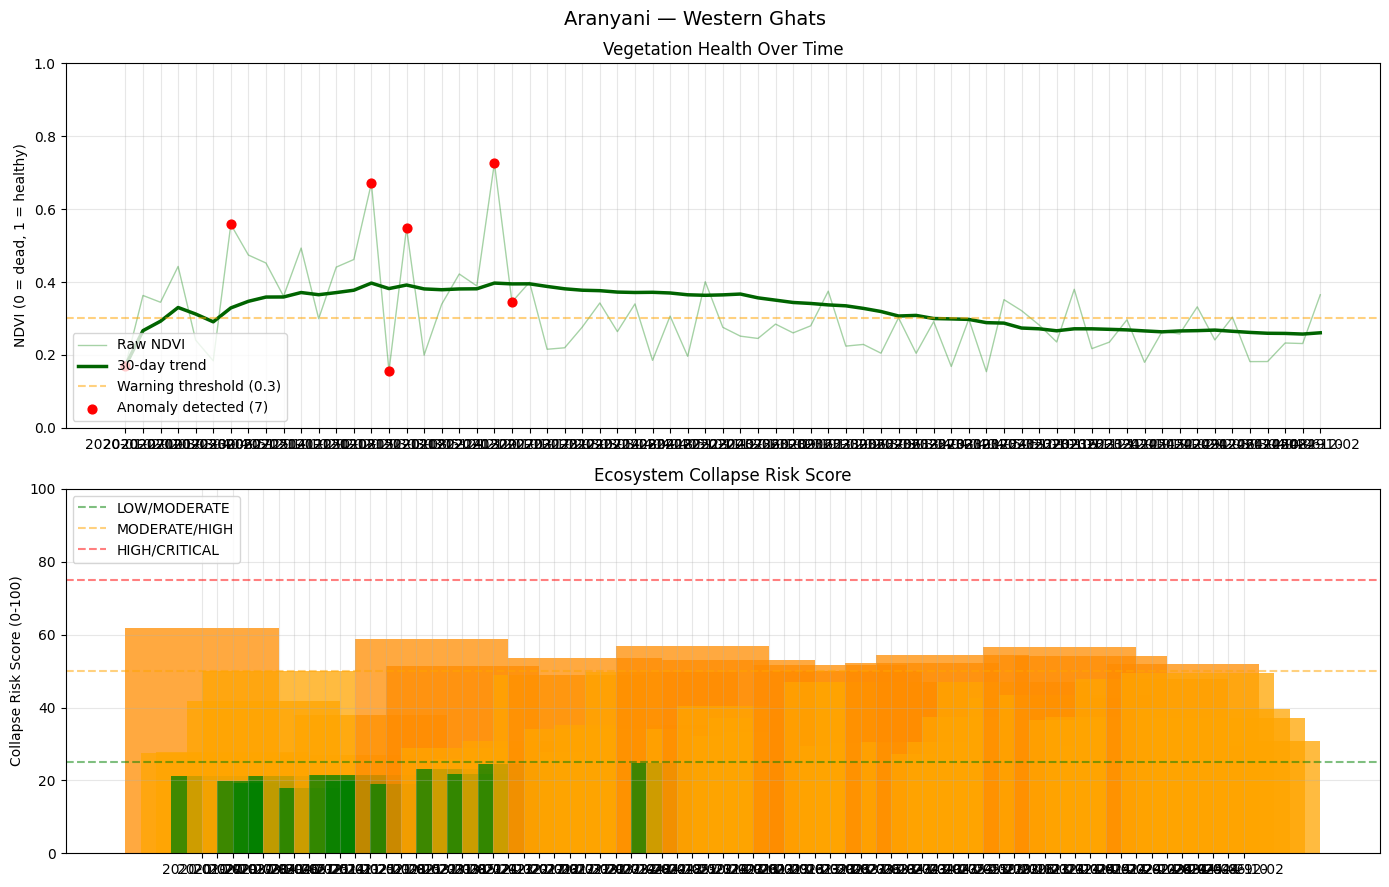

Plot saved: western_ghats_aranyani_results.png


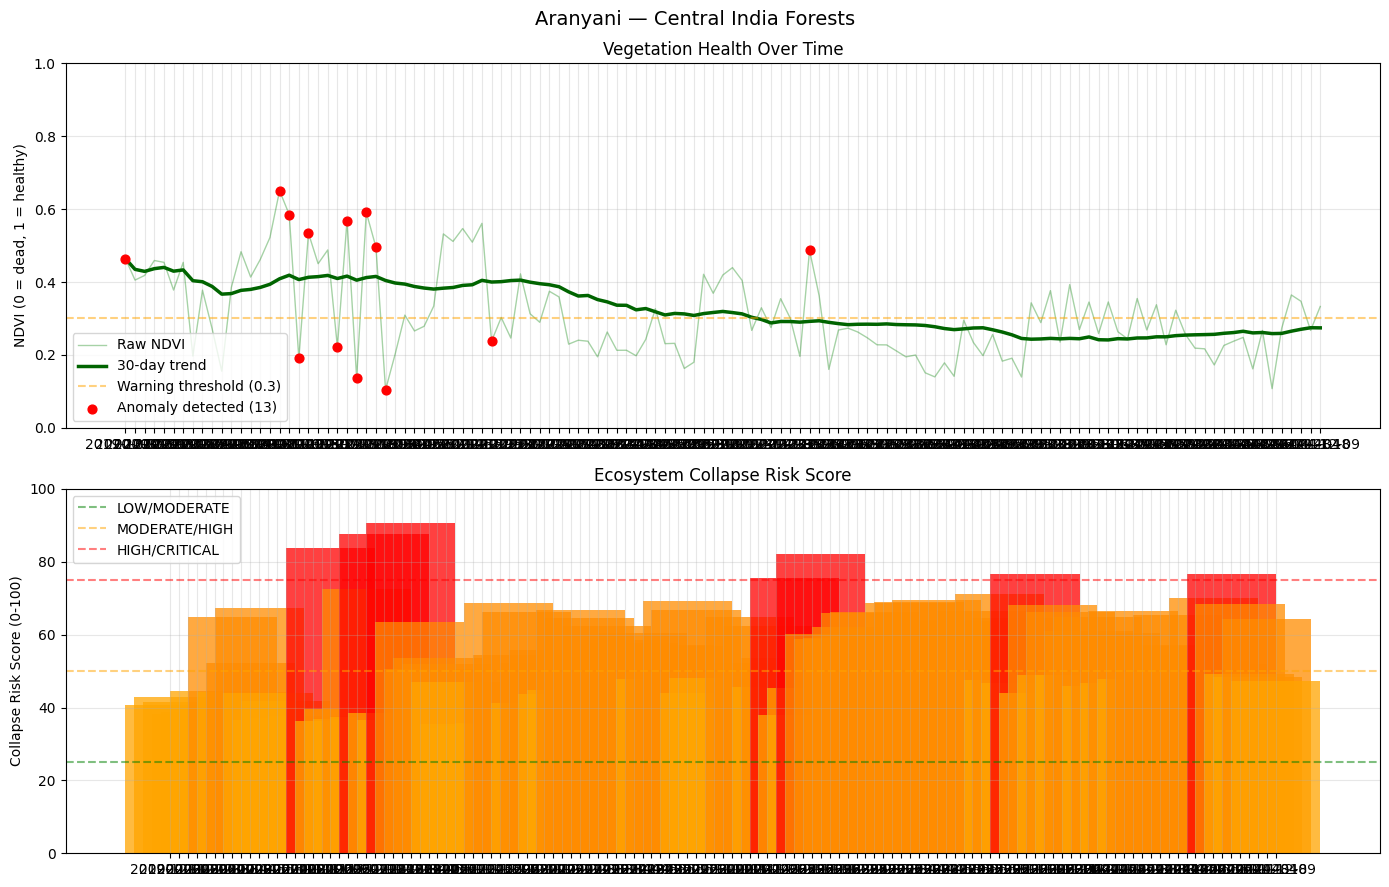

Plot saved: central_india_aranyani_results.png


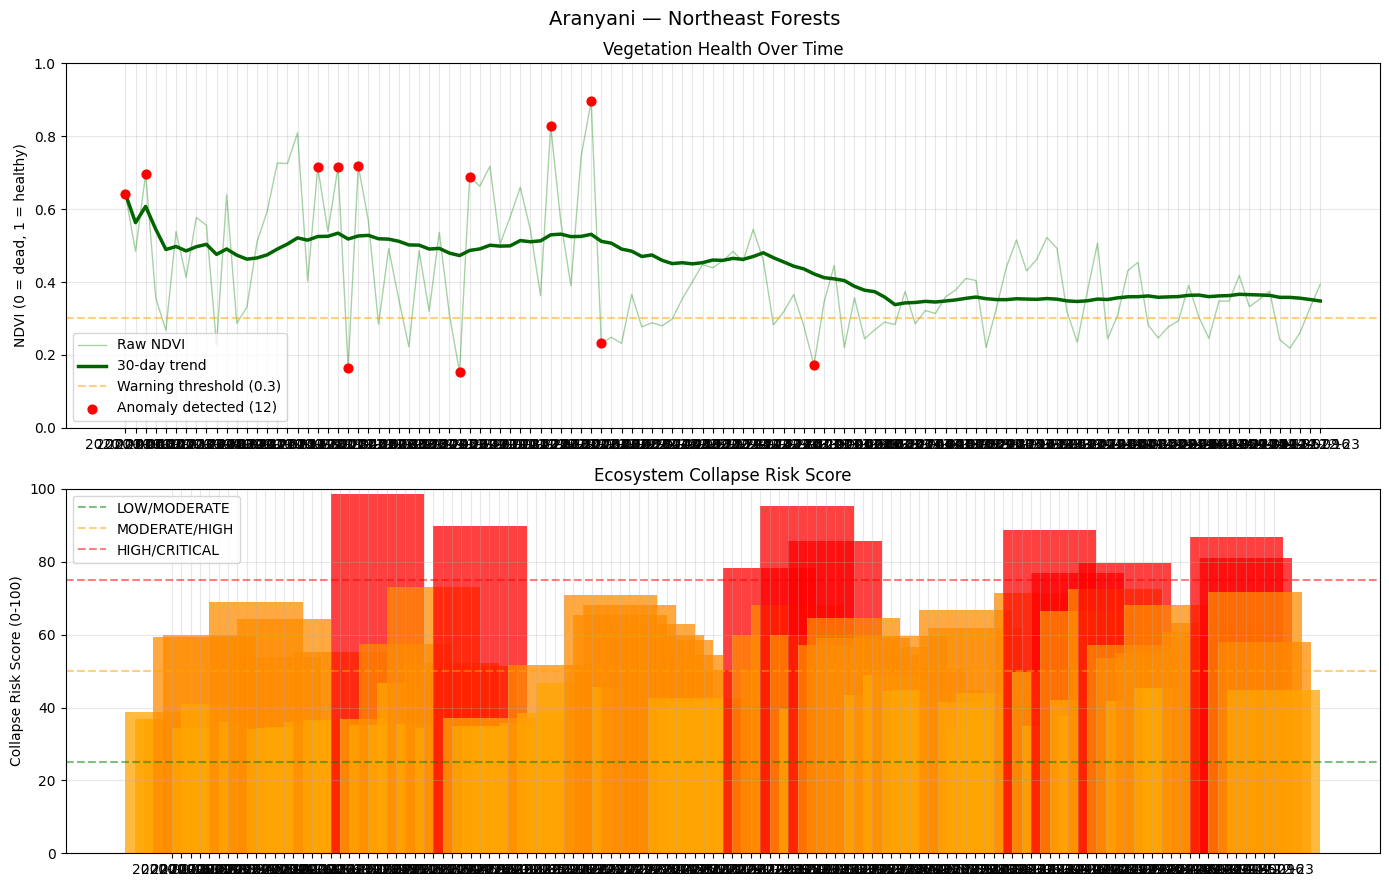

Plot saved: northeast_aranyani_results.png


In [ ]:
#15 th
def plot_results(df, zone_name):
    if len(df) == 0:
        return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))
    fig.suptitle(f"Aranyani — {ZONES[zone_name]['name']}", fontsize=14)

    # --- Plot 1: NDVI Trend ---
    ax1.plot(df["date"], df["ndvi"],
             alpha=0.35, color="green", linewidth=1, label="Raw NDVI")
    ax1.plot(df["date"], df["ndvi_30day"],
             color="darkgreen", linewidth=2.5, label="30-day trend")

    # Shade area below 0.3 as warning zone
    ax1.axhline(y=0.3, color="orange", linestyle="--",
                alpha=0.5, label="Warning threshold (0.3)")

    # Mark anomalies as red dots
    anomalies = df[df["anomaly"] == -1]
    if len(anomalies) > 0:
        ax1.scatter(anomalies["date"], anomalies["ndvi"],
                    color="red", zorder=5, s=40,
                    label=f"Anomaly detected ({len(anomalies)})")

    ax1.set_ylabel("NDVI (0 = dead, 1 = healthy)")
    ax1.set_ylim(0, 1)
    ax1.legend(loc="lower left")
    ax1.grid(True, alpha=0.3)
    ax1.set_title("Vegetation Health Over Time")

    # --- Plot 2: Risk Score ---
    color_map = {
        "LOW":      "green",
        "MODERATE": "orange",
        "HIGH":     "darkorange",
        "CRITICAL": "red"
    }
    bar_colors = df["risk_level"].map(color_map).fillna("gray")

    ax2.bar(df["date"], df["risk_score"],
            color=bar_colors, alpha=0.75, width=10)
    ax2.axhline(y=25, color="green",     linestyle="--", alpha=0.5, label="LOW/MODERATE")
    ax2.axhline(y=50, color="orange",    linestyle="--", alpha=0.5, label="MODERATE/HIGH")
    ax2.axhline(y=75, color="red",       linestyle="--", alpha=0.5, label="HIGH/CRITICAL")

    ax2.set_ylabel("Collapse Risk Score (0-100)")
    ax2.set_ylim(0, 100)
    ax2.legend(loc="upper left")
    ax2.grid(True, alpha=0.3)
    ax2.set_title("Ecosystem Collapse Risk Score")

    plt.tight_layout()
    plt.savefig(f"{zone_name}_aranyani_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved: {zone_name}_aranyani_results.png")

# Plot all 3 zones
plot_results(df_wg, "western_ghats")
plot_results(df_ci, "central_india")
plot_results(df_ne, "northeast")

In [ ]:
#16
def export_final_csv(df, zone_name):
    if len(df) == 0:
        print(f"No data to export for {zone_name}")
        return

    # Select only the columns Person 2 needs
    cols = [
        "date", "zone", "ndvi",
        "ndvi_seasonal_dev", "fire_count",
        "anomaly_score", "risk_score", "risk_level"
    ]

    # Keep only columns that exist
    cols = [c for c in cols if c in df.columns]
    output = df[cols].copy()

    # Convert date to string for JSON compatibility
    output["date"] = output["date"].astype(str)

    filename = f"{zone_name}_risk_scores.csv"
    output.to_csv(filename, index=False)

    latest = output.iloc[-1]
    print(f"\nExported: {filename}")
    print(f"  Total rows:    {len(output)}")
    print(f"  Date range:    {output['date'].min()} to {output['date'].max()}")
    print(f"  Latest score:  {latest['risk_score']}")
    print(f"  Latest level:  {latest['risk_level']}")

# Export all 3 zones
export_final_csv(df_wg, "western_ghats")
export_final_csv(df_ci, "central_india")
export_final_csv(df_ne, "northeast")

print("\n✓ All 3 CSV files ready")
print("Download from Colab: Files panel (left sidebar) → right click → Download")


Exported: western_ghats_risk_scores.csv
  Total rows:    69
  Date range:    2020-01-27 to 2024-12-02
  Latest score:  30.9
  Latest level:  MODERATE

Exported: central_india_risk_scores.csv
  Total rows:    125
  Date range:    2019-12-30 to 2024-12-09
  Latest score:  47.4
  Latest level:  MODERATE

Exported: northeast_risk_scores.csv
  Total rows:    119
  Date range:    2020-01-06 to 2024-12-23
  Latest score:  44.9
  Latest level:  MODERATE

✓ All 3 CSV files ready
Download from Colab: Files panel (left sidebar) → right click → Download


In [ ]:
#17
print("=" * 50)
print("ARANYANI — FINAL RISK SUMMARY")
print("=" * 50)

for zone_name, df in [
    ("western_ghats", df_wg),
    ("central_india",  df_ci),
    ("northeast",      df_ne)
]:
    if len(df) == 0:
        continue
    latest = df.iloc[-1]
    zone   = ZONES[zone_name]
    print(f"\n{zone['name']}")
    print(f"  IKS Region:   {zone['iks_region']}")
    print(f"  Latest NDVI:  {latest['ndvi']:.3f}")
    print(f"  Risk Score:   {latest['risk_score']}/100")
    print(f"  Risk Level:   {latest['risk_level']}")
    print(f"  Anomalies:    {(df['anomaly']==-1).sum()} detected")

print("\n" + "=" * 50)
print("Hand the 3 CSV files to Person 2 (Backend)")
print("=" * 50)

ARANYANI — FINAL RISK SUMMARY

Western Ghats
  IKS Region:   Kerala sacred groves — Kavus
  Latest NDVI:  0.365
  Risk Score:   30.9/100
  Risk Level:   MODERATE
  Anomalies:    7 detected

Central India Forests
  IKS Region:   Gond tribal forest knowledge
  Latest NDVI:  0.333
  Risk Score:   47.4/100
  Risk Level:   MODERATE
  Anomalies:    13 detected

Northeast Forests
  IKS Region:   Khasi sacred forests — Law Kyntang
  Latest NDVI:  0.394
  Risk Score:   44.9/100
  Risk Level:   MODERATE
  Anomalies:    12 detected

Hand the 3 CSV files to Person 2 (Backend)


In [ ]:
print(f"WG fire count:  {df_wg['fire_count'].iloc[0]}")
print(f"CI fire count:  {df_ci['fire_count'].iloc[0]}")
print(f"NE fire count:  {df_ne['fire_count'].iloc[0]}")

WG fire count:  125
CI fire count:  1722
NE fire count:  1934
